<a href="https://colab.research.google.com/github/aka-iriska/plants_disease_recognition/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Обучение модели распознавания болезни растений


## Data

In [1]:
!pip install torch torchvision opencv-python matplotlib scikit-learn kagglehub onnx onnxruntime tqdm seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 101.6 MB/s eta 0:00:00


In [2]:
import kagglehub

download_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


In [3]:
import shutil
import os

source_color_dir = os.path.join(download_path, "plantvillage dataset", "color")
target_dir = "data/color"

if os.path.exists(source_color_dir):
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)

    shutil.copytree(source_color_dir, target_dir)
    print(f"Данные успешно скопированы в {target_dir}")
else:
    print("Папка не найдена. Проверьте структуру через os.listdir(download_path)")

Данные успешно скопированы в data/color


Доступно 38 папок с названием в виде <Название растения>__<healthy/название болезни>. В каждой папке по одному изображению размером 256 на 256 пикселей.

## EDA

In [4]:
from torchvision import datasets

initial_dataset = datasets.ImageFolder(root='data/color')

In [5]:
print(initial_dataset.classes)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

class_counts = {}
for class_name in initial_dataset.classes:
    # Считаем файлы в подпапке каждого класса
    count = len(os.listdir(os.path.join('data/color', class_name)))
    class_counts[class_name] = count

In [7]:
df_stats = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
print(df_stats.describe()) # Общая статистика (среднее, мин, макс)

             Count
count    38.000000
mean   1429.078947
std    1271.738784
min     152.000000
25%     686.000000
50%    1092.500000
75%    1631.500000
max    5507.000000


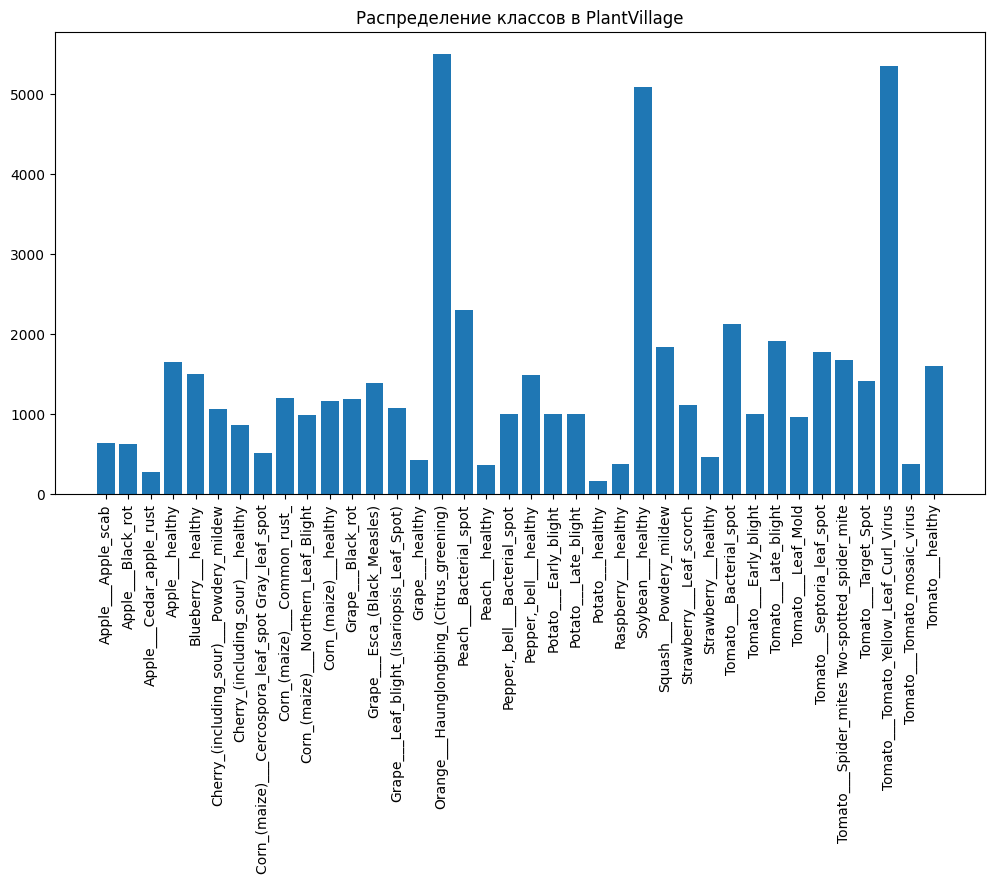

In [8]:
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Распределение классов в PlantVillage")
plt.show()

Как мы можем заметить есть очень большой дисбаланс классов, нам надо его обработать, чтобы модель не училась предугадывать самый популярный класс, а также смогла успеть выучить наименьшие классы.

Применим аугментацию данных, где меньше всего примеров, а также покрутим эти изображения, чтобы модель не заучивала одни и те же картинки.

Тем не менее, манипуляции с данными должны происходить только на обучающей выборке, поэтому разделим `initial_dataset` на train и val выборки.

In [9]:
train_size = int(0.8 * len(initial_dataset))
val_size = len(initial_dataset) - train_size

In [10]:
from torch.utils.data import random_split

train_subset, val_subset = random_split(initial_dataset, [train_size, val_size])

In [11]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5), # Отражение по горизонтали
    transforms.RandomVerticalFlip(p=0.5),   # Отражение по вертикали
    transforms.RandomRotation(30),          # Поворот на случайный угол до 30 градусов
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Небольшое изменение яркости/контраста
    transforms.ToTensor(),
    # Рекомендую добавить нормализацию (параметры для ImageNet)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [12]:
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

"Приклеиваем" трансформации к нашим выборкам

In [13]:
train_subset.dataset

Dataset ImageFolder
    Number of datapoints: 54305
    Root location: data/color

In [14]:
val_subset.dataset

Dataset ImageFolder
    Number of datapoints: 54305
    Root location: data/color

В общем и то, и другое ссылаются на одно и то же, так что придётся создавать копию изначального датасета, чтобы применять разные трансформеры

In [15]:
train_subset.dataset.transform = train_transform

In [17]:
import copy

val_dataset = copy.deepcopy(initial_dataset)
val_dataset.transform = val_transform

val_subset.dataset = val_dataset

In [18]:
val_subset.dataset

Dataset ImageFolder
    Number of datapoints: 54305
    Root location: data/color

Наконец проводим аугментацию данных: создаём семлер только для train

In [19]:
from torch.utils.data import WeightedRandomSampler
import numpy as np
import torch

train_indices = train_subset.indices
train_labels = [initial_dataset.targets[i] for i in train_indices]

class_sample_count = np.array([len(np.where(train_labels == t)[0]) for t in np.unique(train_labels)])
weight = 1. / class_sample_count
samples_weight = torch.from_numpy(np.array([weight[t] for t in train_labels])).double()

sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

In [20]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_subset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_subset, batch_size=32)

In [21]:
from collections import Counter

all_labels = []
for _, labels in train_loader:
    all_labels.extend(labels.tolist())

counts = Counter(all_labels)
# Сортируем так же, как в оригинальном датасете для легкого сравнения
balanced_counts = {initial_dataset.classes[i]: counts[i] for i in range(len(initial_dataset.classes))}

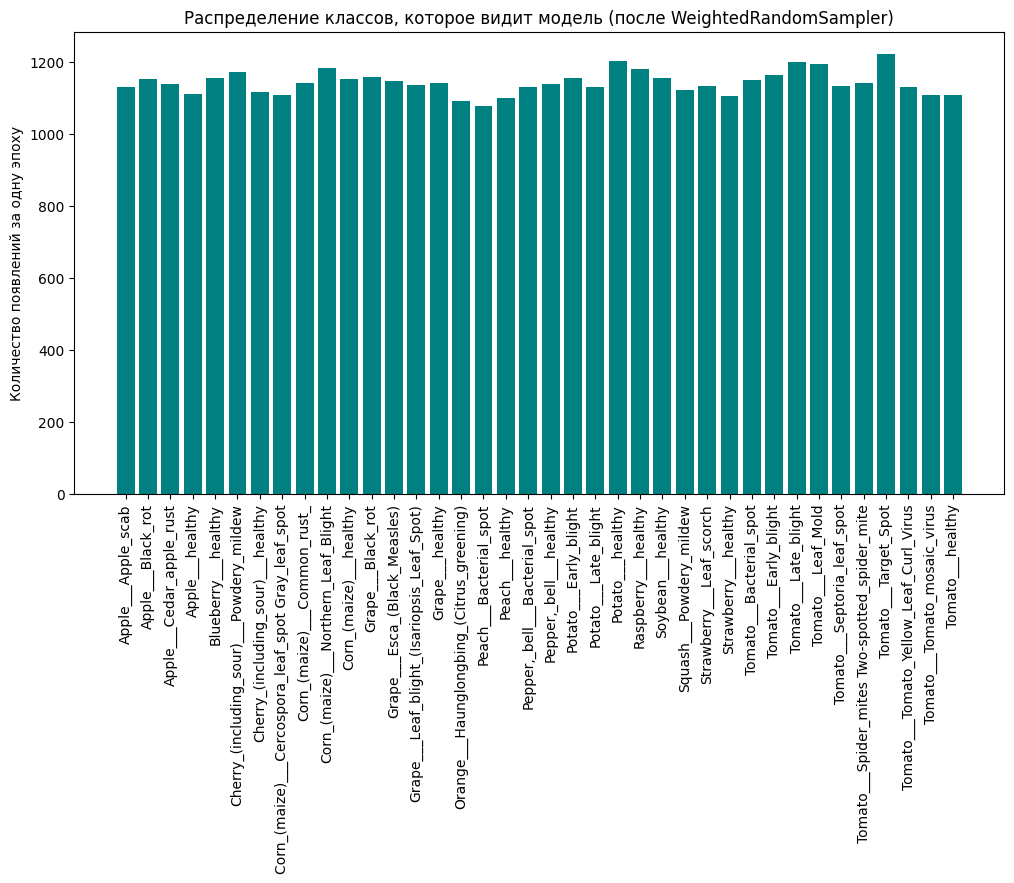

In [22]:
plt.figure(figsize=(12, 6))
plt.bar(balanced_counts.keys(), balanced_counts.values(), color='teal')
plt.xticks(rotation=90)
plt.title("Распределение классов, которое видит модель (после WeightedRandomSampler)")
plt.ylabel("Количество появлений за одну эпоху")
plt.show()

Супер, классы теперь более менее распределены, можно не переживать за дисбаланс :)

## Обучение

Измерим качество нескольких моделей, выберем лучшую и для неё будет тюнить гиперпараметры:
- ResNet50
- EfficientNet-B0
- MobileNetV3

Предполагается, что фермер будет ходить по полю с мобильным устройством, поэтому для анализа берем более легковесные модели.

In [23]:
model_names = ['resnet50', 'efficientnet_b0', 'mobilenet_v3_large']

results = {}

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

Используем устройство: cuda


In [30]:
import copy
from sklearn.metrics import f1_score

def train_model(model, criterion, optimizer, num_epochs=25, patience=5):

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Параметры Early Stopping
    epochs_no_improve = 0
    early_stop = False

    for epoch in range(num_epochs):
        # ФАЗА ОБУЧЕНИЯ
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device) # Перенос на device

            optimizer.zero_grad()            # Обнуляем прошлые градиенты
            outputs = model(inputs)          # Прямой ход (прогноз)
            loss = criterion(outputs, labels) # Считаем ошибку
            loss.backward()                  # Обратный ход (считаем градиенты)
            optimizer.step()                 # Обновляем веса
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_subset)
        history['train_loss'].append(epoch_loss)

        # ФАЗА ВАЛИДАЦИИ
        model.eval()
        running_val_loss = 0.0

        all_preds = []
        all_labels = []

        with torch.no_grad(): # Отключаем расчет градиентов для скорости
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = running_val_loss / len(val_subset)
        val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
        val_f1 = f1_score(all_labels, all_preds, average='macro')

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f'Epoch {epoch}: Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}')

        # Сохраняем
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        # Логика Early Stopping и сохранения лучших весов
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping! No improvement for {patience} epochs.')
                break

    model.load_state_dict(best_model_wts) # загружаем лучшие веса
    return model, history

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import time


for name in model_names:
    print("----------------")
    print(f"Тестируем модель: {name}")

    if name == 'resnet50':
        model = models.resnet50(weights='DEFAULT')
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, 38) # Добавляем новый слой, меняем выход под 38 классов
        head_params = list(model.fc.parameters())
        backbone_params = [p for p in model.parameters() if p not in set(head_params)]

    elif name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='DEFAULT')
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, 38)
        head_params = list(model.classifier[1].parameters())
        backbone_params = [p for p in model.parameters() if p not in set(head_params)]

    elif name == 'mobilenet_v3_large':
        model = models.mobilenet_v3_large(weights='DEFAULT')
        num_ftrs = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(num_ftrs, 38)
        head_params = list(model.classifier[3].parameters())
        backbone_params = [p for p in model.parameters() if p not in set(head_params)]

    model = model.to(device)

    # Настраиваем стандартные параметры
    criterion = nn.CrossEntropyLoss()
    start_time = time.time()

    # Этап 1: только голова, 3 эпохи
    print("Этап 1: обучаем только голову")
    for param in model.parameters():
        param.requires_grad = False
    for param in head_params:
        param.requires_grad = True

    optimizer = torch.optim.Adam(head_params, lr=1e-3)
    train_model(model, criterion, optimizer, num_epochs=3, patience=3)

    # Этап 2: весь backbone с разными LR
    print("Этап 2: файнтюним всю сеть")
    for param in model.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam([
        {'params': backbone_params, 'lr': 1e-5},
        {'params': head_params,     'lr': 1e-4},
    ])
    best_model, history = train_model(model, criterion, optimizer, num_epochs=15, patience=5)

    end_time = time.time()

    best_acc = max(history['val_acc'])

    results[name] = {
    'best_acc': best_acc,
    'time': end_time - start_time,
    'history': history,
    'model_state': best_model.state_dict() # Можно сохранить веса для будущего
    }

    print(f"Модель {name} обучена. Лучшая точность: {best_acc:.4f}, Время: {results[name]['time']:.2f} сек.")

----------------
Тестируем модель: resnet50
Этап 1: обучаем только голову


## Предсказание

## Графики и анализ

## 1. Импорт библиотек

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Если планируете использовать Grad-CAM, раскомментируйте установку:
# !pip install grad-cam

## 2. Визуализация Bounding Box и расчет IoU

IoU (Intersection over Union) используется для оценки качества локализации (где именно находится больной лист на фото). Это отличная визуализация для презентаций!

In [ ]:
def calculate_iou(boxA, boxB):
    # box: [x1, y1, x2, y2]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def visualize_iou(image_path, gt_box, pred_box):
    """
    gt_box - Ground Truth (истинный бокс от разметчика, ЗЕЛЕНЫЙ)
    pred_box - Предсказание нейронки (КРАСНЫЙ)
    """
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    iou = calculate_iou(gt_box, pred_box)

    # Рисуем предсказание (Красный)
    cv2.rectangle(img, (int(pred_box[0]), int(pred_box[1])),
                  (int(pred_box[2]), int(pred_box[3])), (255, 0, 0), 3)
    cv2.putText(img, f'Pred', (int(pred_box[0]), int(pred_box[1])-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    # Рисуем истину (Зеленый)
    cv2.rectangle(img, (int(gt_box[0]), int(gt_box[1])),
                  (int(gt_box[2]), int(gt_box[3])), (0, 255, 0), 3)
    cv2.putText(img, f'GT (IoU: {iou:.2f})', (int(gt_box[0]), int(gt_box[3])+30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("IoU Visualization")
    plt.show()

## 3. Explainable AI: Тепловые карты (Grad-CAM)
Grad-CAM показывает, на какие части изображения модель обратила внимание при предсказании класса. Это особенно важно для диагностики болезней (убедиться, что модель смотрит на пятна, а не на задний фон).

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def show_gradcam(model, target_layer, img_tensor, original_img):
    cam = GradCAM(model=model, target_layers=[target_layer])

    # Предсказываем для самого вероятного класса (или укажите ClassifierOutputTarget(class_idx))
    targets = [ClassifierOutputTarget(2)] # Пример: класс 2

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    # Наложение
    img_normalized = np.float32(original_img) / 255
    visualization = show_cam_on_image(img_normalized, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title('Grad-CAM Heatmap')
    plt.axis('off')
    plt.show()

## 4. Заготовка для K-Fold Validation
Если у вас небольшой датасет и вы хотите использовать K-Fold (например, $K=5$).

In [ ]:
from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader

# Предположим, у нас есть full_dataset (экземпляр Dataset)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_ids, val_ids) in enumerate(kfold.split(np.arange(100))): # 100 - длина датасета
    print(f'FOLD {fold}')
    print('--------------------------------')

    # train_sub = Subset(full_dataset, train_ids)
    # val_sub = Subset(full_dataset, val_ids)

    # trainloader = DataLoader(train_sub, batch_size=32, shuffle=True)
    # valloader = DataLoader(val_sub, batch_size=32, shuffle=False)

    # Дальше идет инициализация модели и стандартный цикл обучения (epochs)
    # ...

    break # Для примера пройдем только 1 фолд

## 5. Экспорт модели в ONNX для использования в Production
ONNX не требует PyTorch в production-среде (например, в Docker-контейнере с FastAPI).

In [ ]:
def export_to_onnx(model, save_path="weights/plant_model.onnx"):
    model.eval()

    # Создаем фиктивный тензор той же размерности, что и вход модели
    # Например: Batch_Size=1, Channels=3, H=224, W=224
    dummy_input = torch.randn(1, 3, 224, 224, device='cpu')

    torch.onnx.export(
        model,
        dummy_input,
        save_path,
        export_params=True,
        opset_version=14,          # Opset версия (11-14 обычно безопасны)
        do_constant_folding=True,  # Оптимизация графа
        input_names=['input'],     # Имя входного узла
        output_names=['output'],   # Имя выходного узла
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        } # Поддержка динамического размера батча
    )
    print(f"Модель успешно экспортирована в {save_path}!")

# Пример вызова:
# model = torchvision.models.resnet18(pretrained=True)
# export_to_onnx(model)